# Data exploration and cleaning
We will demonstrate building models using freely available datasets.

It very often happens that raw data contains errors, some data is missing, data is in the wrong format, etc.

Before you start working with data, it is always good to understand it and adjust it if necessary.

There are a whole range of freely available data sources on the internet where you can try out your skills.
- https://archive.ics.uci.edu/ml/index.php
- https://www.kaggle.com/
- https://toolbox.google.com/datasetsearch
- github datasets

## Boston Housing Dataset

The housing dataset is derived from information about housing in the Boston, Massachusetts area, collected by the U.S. Census Bureau.

The data was originally published in an article by Harrison, D. and Rubinfeld, D.L. `Hedonic prices and the demand for clean air', J. Environ. Economics & Management, vol.5, 81-102, 1978.

The dataset contains information about 506 different houses in Boston.

Dataset features
* CRIM - per capita crime rate by town
* ZN - proportion of residential land zoned for lots over 25,000 sq. ft.
* INDUS - proportion of non-retail business acres per town
* CHAS - Charles River dummy variable (1 if tract bounds the river; 0 otherwise)
* NOX - nitrogen oxide concentration (parts per 10 million)
* RM - average number of rooms per dwelling
* AGE - proportion of owner-occupied units built before 1940
* DIS - weighted distances to five Boston employment centers
* RAD - index of accessibility to radial highways
* TAX - full-value property tax rate per $10,000
* PTRATIO - pupil-teacher ratio by town
* B - 1000(Bk - 0.63)^2, where Bk is the proportion of Black residents by town.
* LSTAT - percentage of lower-status population
* MEDV - median value of owner-occupied homes in $1000s

## Reading data from a CSV file

In [ ]:
import pandas as pd 

In [ ]:
data = pd.read_csv (r"..\dataset\HousingData.csv")

Let's look at the structure of the file.

In [ ]:
data.info()

## Basic characteristics of the data

Before building a model, it is a good idea to have an understanding of the input data. This can prevent later problems.

- Some models, for example, require a specific data format. Most mathematical models cannot work with text information.
- Some information may be unavailable. NaN values
- Some models are sensitive to biased extreme values.
- There may be errors in the data. E.g. a wrong data range (negative age). Faulty data (strings in numbers, invalid date, unexpected values, ...)

Displaying a preview of the data. Some errors are visible at first glance.

In [ ]:
data.head(10)

Some errors will be apparent from the basic statistics of the data.

The basic statistics of the data in the columns are displayed using the `describe` function.
- number of records
- mean value - average
- variance
- minimum
- 25th percentile
- 50th percentile - median
- 75th percentile
- maximum

In the example below we can notice: 

- For some columns, the mean and median differ significantly - CRIM, ZN
- For some columns, the mean and median are similar - RM

Some characteristics are well visible when displaying the distribution of values, which we will show next.

In [ ]:
data.describe()

Some columns contain NULL data. We must decide how to solve this problem. In our case, this concerns missing data in the columns (CRIM, ZN, INDUS, CHAS, AGE, LSTAT).
* Incomplete rows can be removed from the dataset.
* Problematic columns should not be input parameters of the model. So we can remove problematic columns.
* Missing values could be replaced with artificial values such as the mean, zeros, ...
* ...

In [ ]:
data.isna().sum()

## Distribution of values

Visualizing the distribution of data in columns could reveal skewed, abnormal values.

At the same time, some statistical methods may not work correctly on atypically distributed data.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

The distribution of data can be well understood from charts.

We will create a chart that combines a histogram with an estimate of the distribution function.

We obtain the estimate of the distribution function using the seaborn library and a kernel density estimate line.

From the charts we can see that some variables have an almost normal distribution (RM), others have an almost uniform one (NOX).

Some variables have a large proportion of small values, and high values are almost absent in the dataset (CRIM).

For some variables we can see that maximum values are heavily represented (B, TAX).

In [ ]:
pos = 1
fig = plt.figure(figsize=(16,24))
for i in data.columns:
    ax = fig.add_subplot(7,2, pos)
    pos = pos + 1
    sns.histplot(data[i], ax=ax, kde=True)

Similar information can also be gleaned from a boxplot. Although the distribution details are not as fine-grained, the chart is compact. Moreover, outlier values can be read from it very nicely.

That's why it appears very often in academic articles, when you need to present data in a small space.

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)

## Data cleaning and standardization

### Data cleaning
Some columns contain NULL data. We must decide how to solve this problem.
* Incomplete rows can be removed from the dataset.
* Problematic columns should not be input parameters of the model.
* Records with extreme values can be excluded from the dataset. For example, because they are measurement errors.

In [ ]:
data=data.dropna()
print (data.isnull().sum())

Out of 506 records, we are left with 394 complete records.

In [ ]:
data.describe()

Sometimes it is useful to exclude data with extreme values. These can arise, for example, from measurement error, various anomalies, heterogeneity of the input data, etc.

For example, if we want to predict age based on height, the model will work well for individuals up to adulthood. The relationship between height and age for adults gradually disappears.

**Sometimes extreme values can, on the contrary, be important.** If we remove some data, we must have a reason for it. Or we can create two models, one with all the data and one with the removed data, and compare them.

We will remove rows from the dataset where the median house value is higher than 45. These are apparently a few luxury houses, and in the input data we do not have a variable that would, for example, describe luxuriousness (quality, material, the original owner was a celebrity, ...).

When we then build a prediction model, we must be aware that it is not intended for luxury houses. Those differ from ordinary houses in Boston.

In [ ]:
data = data[~(data['MEDV'] >= 45.0)]

After removing extreme prices, we have 379 records in the dataset.

In [ ]:
data.describe()

Sometimes a dataset contains columns that have no relationship to the explained variable. For example, a record ID, collection time, etc. Again, we can drop this information from the dataset.

### Data standardization

Each input variable has a different mean value and standard deviation.

Before feeding data into a mathematical model, it is good practice to perform standardization.

Reasons:
* prevent some variables from dominating the model
* can help machine learning models converge faster
* can make it easier to interpret the coefficients of a machine learning model

Calculation:
* x_new = (x – mean) / standard_deviation
* mean = sum(x) / count(x)
* standard_deviation = sqrt( sum( (x – mean)^2 ) / count(x))

We can do standardization manually. We calculate the mean and deviation and adjust the data. 

In [ ]:
data["AGE"].mean()

In [ ]:
data["AGE"].std()

In [ ]:
data['AGE_STD'] = (data['AGE'] - data['AGE'].mean()) / data['AGE'].std()
data['LSTAT_STD'] = (data['LSTAT'] - data['LSTAT'].mean()) / data['LSTAT'].std()

We can look at the distribution charts to see how the original data changed into the new data.

The shape of the chart is identical, but the standardized chart is relatively centered around the value 0.

In [ ]:
fig = plt.figure (figsize=(10, 5))
axes = fig.subplots (1, 2)           
ax1 = axes[0]
ax2 = axes[1]
sns.histplot(data['AGE'],ax=ax1, kde=True)
sns.histplot(data['AGE_STD'],ax=ax2, kde=True)

We will display the same for LSTAT

In [ ]:
fig = plt.figure (figsize=(10, 5))
axes = fig.subplots (1, 2)           
ax1 = axes[0]
ax2 = axes[1]
sns.histplot(data['LSTAT'],ax=ax1, kde=True)
sns.histplot(data['LSTAT_STD'],ax=ax2, kde=True)

We will delete the manually created standardized columns. We created them only for demonstration purposes.

In [ ]:
data = data.drop(columns=["AGE_STD", "LSTAT_STD"])

The demonstration helped us understand the effect of standardization. Now we will standardize the entire input dataset using `StandardScaler`.

We save the scaler to a file — when predicting new data, we must use the **same parameters** (mean and deviation) that were calculated from the training data.

In [ ]:
import joblib
from sklearn.preprocessing import StandardScaler

# separate features and target
X = data.drop(columns=["MEDV"])
y = data["MEDV"]

# fit scaler on all input features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# save scaler
joblib.dump(scaler, "scaler.pkl")

X_scaled.describe().round(2)

## Relationships between variables
Datasets tend to have a great many variables. It often happens that there is some relationship between them. If one variable changes, another variable is likely to change as well.

These relationships may or may not have a causal connection. Sometimes it can also be a coincidence.

Therefore it is good to try to uncover these relationships.
* Detecting dependencies – we find out whether a change in one variable is related to a change in another (e.g. height and weight).
* Redundancy – strongly correlated variables often carry the same information → there is no need to have both when modeling.
* Prediction – if one variable is strongly related to another, we can use it for prediction (e.g. age ↔ income).
* Hidden relationships – weak or no correlation may mean the dependency is non-linear or is influenced by other factors.

There are a whole range of methods for uncovering dependencies.

Let's start by creating charts for all combinations of two features.

The human brain is trained to look for patterns. It may happen that we see some relationship at first glance.

Generally we are looking for a chart shape that displays some mathematical curve (line, parabola, hyperbola, etc.)

In [ ]:
sns.pairplot(data)

From the charts we can see that there is a certain direct proportionality between RM, LSTAT and MEDV.

* RM - average number of rooms per dwelling (input variable)
* LSTAT - percentage of lower-status population (input variable)
* MDEV - median value of owner-occupied homes in $1000s (output variable)

We estimated the relationships between variables by eye. But it can also be done exactly using correlation.

Correlation shows us how strongly, and in which direction, two (or more) variables are **linearly** dependent. Note that some phenomena may not have a linear dependency, but a different one. The correlation coefficient will not work for a type of relationship other than linear.

Correlation coefficient (Pearson's r):
* Values from -1 to 1
* r ≈ 1 → strong positive linear dependency
* r ≈ -1 → strong negative linear dependency
* r ≈ 0 → no linear dependency (but there may be a non-linear one)

In [ ]:
corr = data.corr(numeric_only=True)
corr

A strong direct or inverse correlation can indicate a relationship between input parameters.
This can help us when choosing the model's input parameters.

Sometimes it can be useful to display correlations using a heatmap.
Especially if the correlation matrix is large, colors can help us orient ourselves.

In [ ]:
plt.figure(figsize = (10,8))
sns.heatmap(corr.abs(), annot=True, vmin=0, vmax=1)

For example, the CHAS column (the Charles River dummy variable) has no relationship with other features.

On the other hand, the columns LSTAT, TAX, RAD, NOX, INDUS have relationships with other columns.

In the next lesson, we will try to build a statistical model that will estimate the property price MEDV based on input parameters.

We will use linear regression for this.

If we focus on the MEDV row, suitable input parameters could be the columns RM, LSTAT.

## Variance Inflation Factor (VIF)

The correlation matrix shows only **pairwise** relationships (one variable against another). VIF goes further — it measures how well one variable can be **linearly explained by all the other** input variables combined.

Interpretation:
| VIF | Conclusion |
|-----|-------|
| 1 | no multicollinearity |
| 1 – 5 | acceptable collinearity |
| 5 – 10 | increased collinearity — consider excluding the variable |
| > 10 | problematic multicollinearity |

A high VIF means that the variable is redundant — the information it carries is also carried by the other variables. The model may be unstable.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame({
    "feature": X_scaled.columns,
    "VIF": [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
})
vif.sort_values("VIF", ascending=False).reset_index(drop=True)

There is a lot of multicollinearity in the Boston dataset. Only variables under a VIF of 3 are acceptable.

We can then continue in various directions.
- We accept the fact that the input variables are very intertwined and the resulting model may not be of good quality.
- We select only some variables, ideally those that are correlated with the explained variable and are not correlated with each other.
- We do an exploratory factor analysis to better understand the relationships. EFA creates groups of interconnected variables.
- We perform Principal Component Analysis (PCA). This will be covered in later lessons.

## Exploratory Factor Analysis (EFA)

### What is a factor?

A **factor** is a hidden (latent) variable that we do not measure directly, but which influences multiple measured variables at once. It is essentially a hypothesis about the cause of the observed correlations.

Analogy: "intelligence" is a factor that we do not measure directly, but it manifests itself in test results in math, language, and logic — all three tests correlate with each other precisely because they share this common underlying basis.

In the Boston Housing dataset:
- the variables **INDUS, NOX, TAX, RAD** correlate strongly with each other → they probably share the factor "industrial character of the area"
- the variables **RM, LSTAT, MEDV** correlate differently → the factor "housing quality"

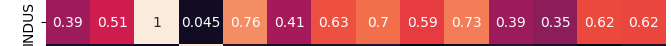

EFA asks: *How many such hidden factors exist, and which variables belong to them?*


### Output of the analysis

The main output is the **loadings matrix**:
- rows = measured variables (CRIM, NOX, RM, ...)
- columns = the factors found (Factor 1, Factor 2, ...)
- value = correlation of the variable with the factor, a number from −1 to 1

| loading | interpretation |
|---------|-------------|
| > 0.6 | the variable strongly "belongs" to this factor |
| 0.3 – 0.6 | medium association |
| < 0.3 | weak association, usually ignored |

We name the resulting factors ourselves — based on which variables have high loadings on them.


### Procedure

1. **Scree plot** + Kaiser criterion → choice of the number of factors (eigenvalue > 1)
2. **Fitting the model** with varimax rotation (maximizes the contrast of loadings, improves interpretability)
3. **Loadings matrix, communality** — we read off which variables belong to which factor, and we name the factors
4. **Factor scores** - transformation of the original data into factors

In [ ]:
import numpy as np

# eigenvalues of the correlation matrix
corr_matrix = np.corrcoef(X_scaled.T)
eigenvalues = np.sort(np.linalg.eigvalsh(corr_matrix))[::-1]

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker="o")
plt.axhline(y=1, color="red", linestyle="--", label="Kaiser criterion (eigenvalue = 1)")
plt.xlabel("Factor number")
plt.ylabel("Eigenvalue")
plt.title("Scree plot")
plt.legend()
plt.tight_layout()
plt.show()

n_factors = int((eigenvalues > 1).sum())
print(f"Number of factors with eigenvalue > 1: {n_factors}")

### Loadings matrix
The loadings matrix is calculated from the standardized values.

In [ ]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=n_factors, rotation="varimax")
fa.fit(X_scaled)

loadings = pd.DataFrame(
    fa.components_.T,
    index=X_scaled.columns,
    columns=[f"Factor {i + 1}" for i in range(n_factors)]
)
loadings.round(2)

Visualizing the loadings

A heatmap of the loadings makes interpretation easier. Red = strong positive association, blue = negative. Variables in the same column (factor) form a natural group — they probably share the same latent cause.

In [ ]:
plt.figure(figsize=(4, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Factor loadings (varimax rotation)")
plt.tight_layout()
plt.show()

### Communality

**Communality** (h²) tells us what proportion of a given variable's variance is explained by all the factors combined.

Calculation: h²ᵢ = Σ loadingᵢⱼ²  (sum of the squared loadings across all factors)

| h² | Interpretation |
|----|-------------|
| > 0.7 | the variable is well captured by the factors |
| 0.4 – 0.7 | medium explanation |
| < 0.4 | the variable stands outside the found factors — consider excluding it or a different number of factors |

Communality helps us verify whether the chosen number of factors sufficiently covers the information contained in the data.

In [ ]:
communality = (loadings ** 2).sum(axis=1)

communality_df = pd.DataFrame({"communality": communality.round(2)}).sort_values(
    "communality", ascending=False
)
communality_df

# Factor scores — new data for regression

Factors can be understood as **new computed variables**. Instead of the 13 original (strongly correlated) columns, we get `n_factors` new factor columns.

Each row (house) gets a value for each factor — how much each latent factor is expressed in that particular house.

**Advantage for regression:**
- The factors are less correlated with each other than the original variables → lower multicollinearity
- Fewer input variables → a simpler model
- Trade-off: we lose the direct interpretation of the original columns (we work with "Housing quality" instead of concrete values of RM and LSTAT)

In [ ]:
factor_scores = fa.transform(X_scaled)

factor_df = pd.DataFrame(
    factor_scores,
    columns=[f"Factor {i + 1}" for i in range(n_factors)],
    index=X_scaled.index
)

print(f"Original shape: {X_scaled.shape}")
print(f"Factor scores shape: {factor_df.shape}")
factor_df.head(10)

Saving the found transformation for later use

In [ ]:
joblib.dump(fa, "fa.pkl")